In [1]:
# Install ALL required packages
import subprocess, sys

packages = [
    'seaborn',
    'imbalanced-learn',
    'xgboost',
    'scipy',
    'joblib',
    'google-cloud-storage',
]
for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('\n✅ All packages installed successfully.')

GCS_BUCKET = 'ml-fraud-detection-2026-qass'   
GCS_BLOB   = 'creditcard.csv'    

# Download CSV from GCS to local VM disk
from google.cloud import storage
import os

LOCAL_CSV = '/home/jupyter/creditcard.csv'

if not os.path.exists(LOCAL_CSV):
    client = storage.Client()
    bucket = client.bucket(GCS_BUCKET)
    blob   = bucket.blob(GCS_BLOB)
    blob.download_to_filename(LOCAL_CSV)
    print(f'\n✅ Downloaded creditcard.csv from gs://{GCS_BUCKET}/{GCS_BLOB}')
else:
    print(f'\n✅ CSV already present at {LOCAL_CSV}')

print(f'LOCAL_CSV = {LOCAL_CSV}')
print('\n🚀 Ready! Now run the remaining cells.')


Installing seaborn...
Installing imbalanced-learn...
Installing xgboost...
Installing scipy...
Installing joblib...
Installing google-cloud-storage...

✅ All packages installed successfully.

✅ CSV already present at /home/jupyter/creditcard.csv
LOCAL_CSV = /home/jupyter/creditcard.csv

🚀 Ready! Now run the remaining cells.


In [2]:
# CELL 1: Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(LOCAL_CSV)
print(f"Shape: {df.shape}")
print(f"\nClass Distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud Rate: {df['Class'].mean()*100:.3f}%")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")

Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud Rate: 0.173%

Missing Values: 0

Duplicates: 1081


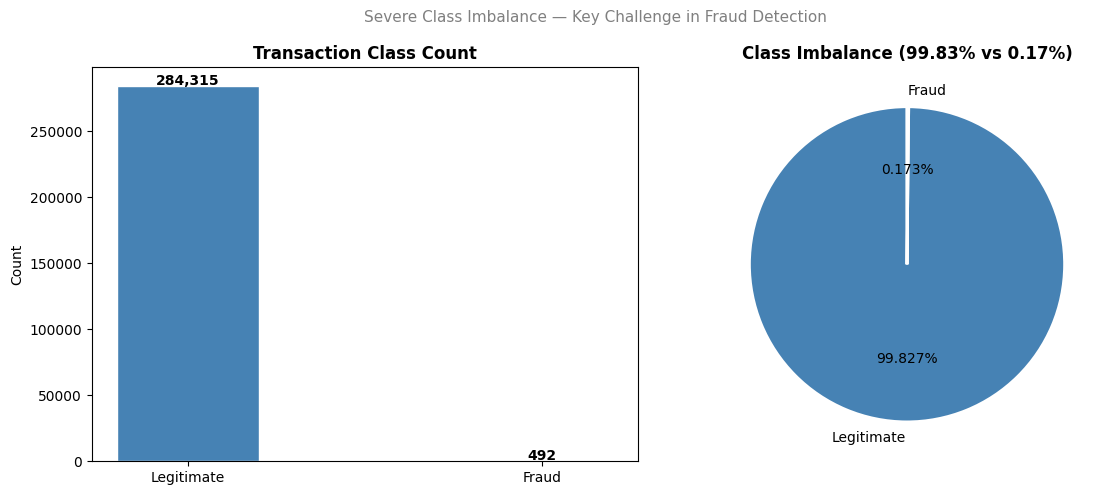

In [3]:
# CELL 2: Class Imbalance — Bar + Pie
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Class'].value_counts()
labels = ['Legitimate', 'Fraud']
colors = ['steelblue', 'tomato']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.4)
axes[0].set_title('Transaction Class Count', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Imbalance (99.83% vs 0.17%)', fontweight='bold')

plt.suptitle('Severe Class Imbalance — Key Challenge in Fraud Detection',
             color='gray', fontsize=11)
plt.tight_layout()
plt.show()

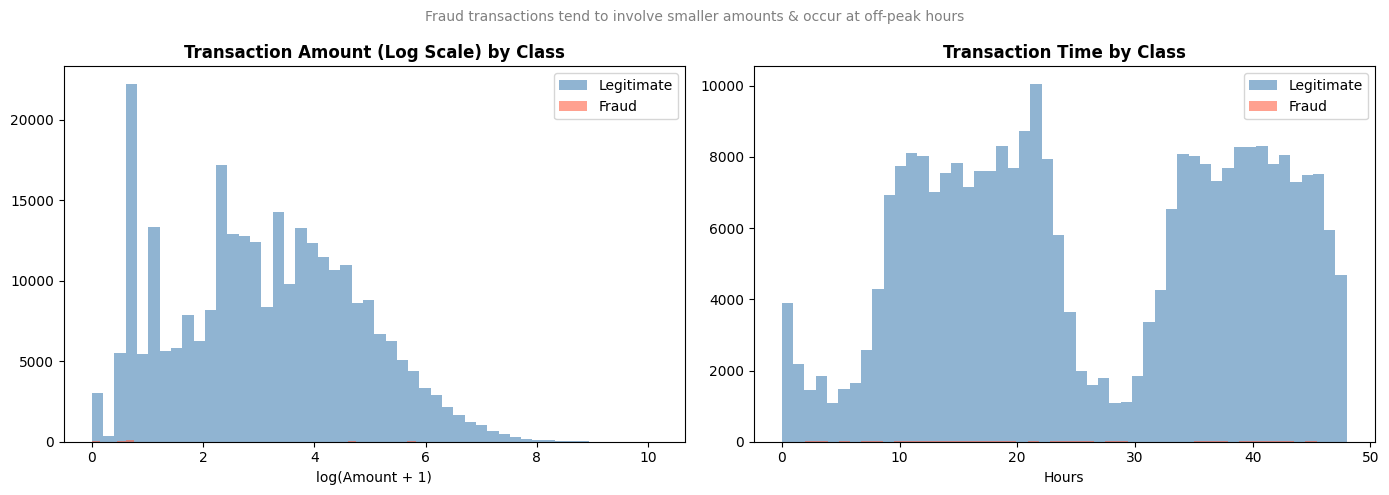

In [4]:
# CELL 3: Histograms — Amount & Time by Class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['Legitimate', 'Fraud']):
    subset = df[df['Class'] == label]
    axes[0].hist(np.log1p(subset['Amount']), bins=50, alpha=0.6, color=color, label=name)
    axes[1].hist(subset['Time'] / 3600, bins=50, alpha=0.6, color=color, label=name)

axes[0].set_title('Transaction Amount (Log Scale) by Class', fontweight='bold')
axes[0].set_xlabel('log(Amount + 1)')
axes[0].legend()

axes[1].set_title('Transaction Time by Class', fontweight='bold')
axes[1].set_xlabel('Hours')
axes[1].legend()

plt.suptitle('Fraud transactions tend to involve smaller amounts & occur at off-peak hours',
             color='gray', fontsize=10)
plt.tight_layout()
plt.show()

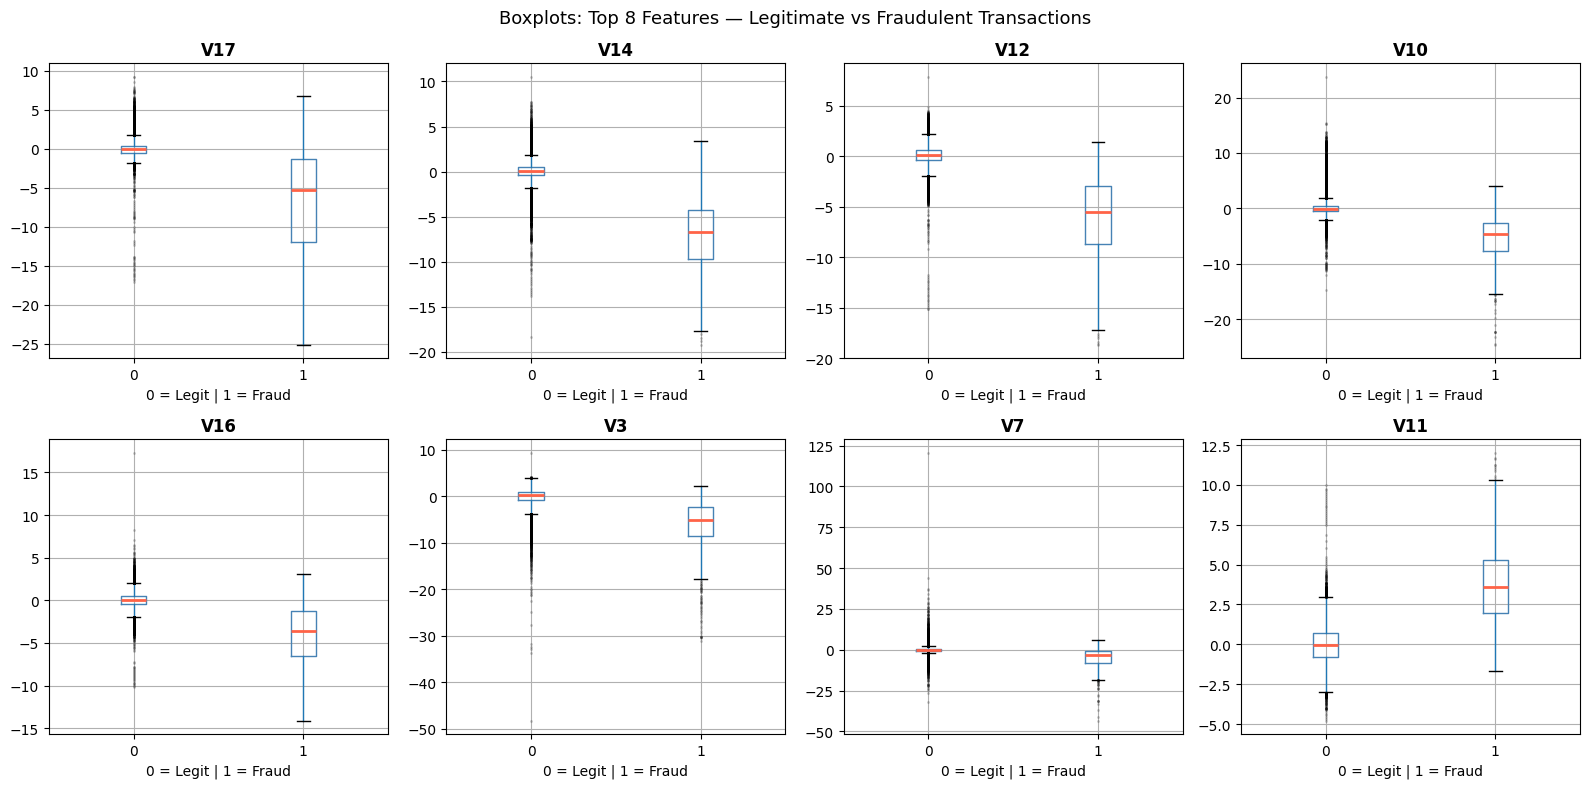

In [5]:
# CELL 4: Boxplots — Top 8 features most correlated with fraud
top_features = (df.corr()['Class']
                .drop('Class')
                .abs()
                .sort_values(ascending=False)
                .head(8).index.tolist())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by='Class', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='o', markersize=1, alpha=0.2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('0 = Legit | 1 = Fraud')

plt.suptitle('Boxplots: Top 8 Features — Legitimate vs Fraudulent Transactions', fontsize=13)
plt.tight_layout()
plt.show()

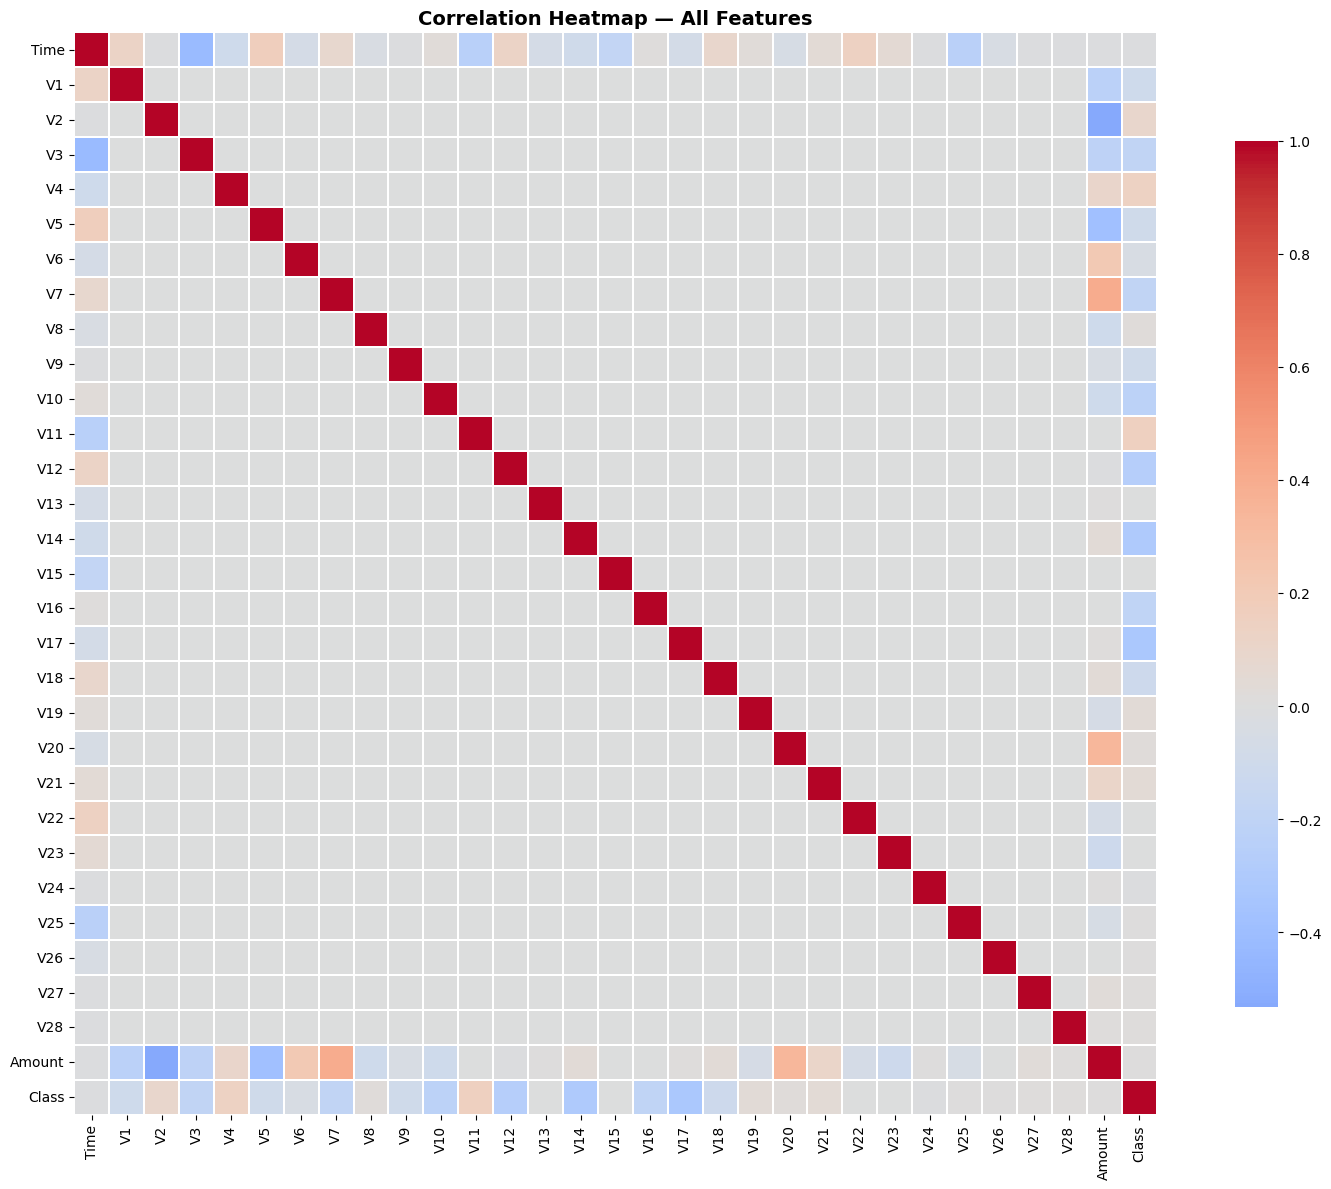

Top 10 features correlated with Fraud:
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


In [6]:
# CELL 5: Correlation Heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(df.corr(),
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            square=True,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Heatmap — All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 features correlated with Fraud:")
print(df.corr()['Class'].drop('Class').abs()
      .sort_values(ascending=False).head(10).round(4))

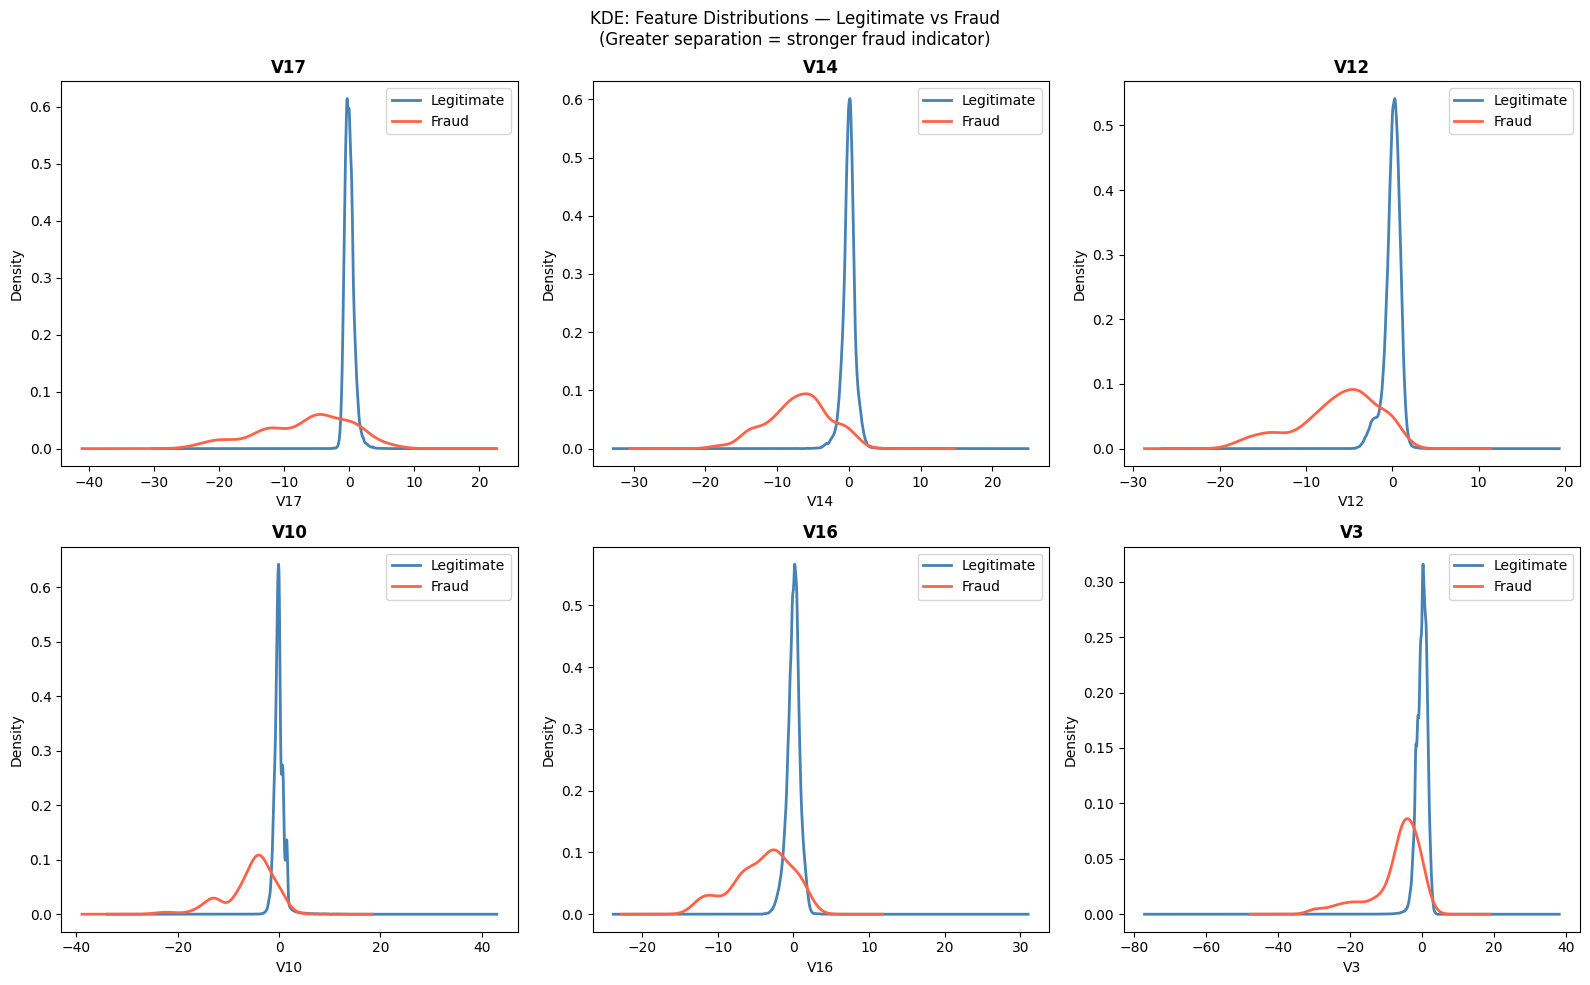

In [7]:
# CELL 6: KDE Plots — Fraud vs Legitimate separation (research standard)
top6 = (df.corr()['Class']
        .drop('Class')
        .abs()
        .sort_values(ascending=False)
        .head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    df[df['Class'] == 0][col].plot(kind='density', ax=axes[i],
                                    label='Legitimate', color='steelblue', linewidth=2)
    df[df['Class'] == 1][col].plot(kind='density', ax=axes[i],
                                    label='Fraud', color='tomato', linewidth=2)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(col)

plt.suptitle('KDE: Feature Distributions — Legitimate vs Fraud\n'
             '(Greater separation = stronger fraud indicator)', fontsize=12)
plt.tight_layout()
plt.show()

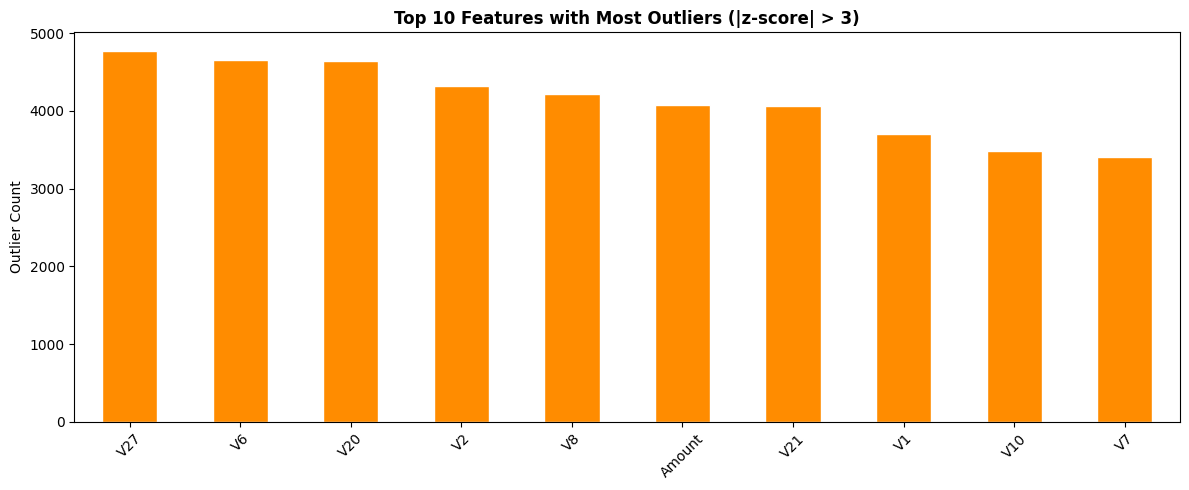


Outlier Summary:
V27       4771
V6        4652
V20       4645
V2        4318
V8        4221
Amount    4076
V21       4064
V1        3701
V10       3488
V7        3401
dtype: int64

Total outlier instances across all features: 83,598


In [8]:
# CELL 7: Outlier / Anomaly Summary
from scipy import stats

z_scores = np.abs(stats.zscore(df.drop('Class', axis=1)))

# Fix: convert back to DataFrame first
outlier_counts = (pd.DataFrame(z_scores, columns=df.drop('Class', axis=1).columns) > 3).sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
outlier_counts.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 10 Features with Most Outliers (|z-score| > 3)', fontweight='bold')
plt.ylabel('Outlier Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nOutlier Summary:")
print(outlier_counts)
print(f"\nTotal outlier instances across all features: {(z_scores > 3).sum():,}")

In [9]:
# CELL 8: Remove Duplicates & Baseline Check
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")
print(f"Class distribution after dedup:\n{df['Class'].value_counts()}")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

Shape after removing duplicates: (283726, 31)
Class distribution after dedup:
Class
0    283253
1       473
Name: count, dtype: int64
Fraud rate: 0.167%


In [10]:
# CELL 9: Feature Engineering
import pandas as pd
import numpy as np

# Time-based features
df['Hour'] = (df['Time'] % 86400) // 3600          # Hour of day (0-23)
df['IsNight'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)  # Night flag

# Amount-based features
df['LogAmount'] = np.log1p(df['Amount'])            # Log transform (right-skewed)
df['AmountBin'] = pd.cut(df['Amount'],
                          bins=[0, 10, 50, 200, 1000, np.inf],
                          labels=['micro', 'small', 'medium', 'large', 'very_large'])

# Interaction features (top correlated V-features from EDA)
top_v = ['V14', 'V17', 'V12', 'V10', 'V16', 'V3']
for i in range(len(top_v)):
    for j in range(i+1, len(top_v)):
        col = f'{top_v[i]}_{top_v[j]}_interaction'
        df[col] = df[top_v[i]] * df[top_v[j]]

# Outlier flag — mark extreme z-score rows as a feature
from scipy import stats
z = np.abs(stats.zscore(df[['Amount', 'LogAmount']]))
df['IsOutlier'] = (z > 4).any(axis=1).astype(int)

print(f"New feature set shape: {df.shape}")
print(f"\nNew features added:")
new_cols = ['Hour', 'IsNight', 'LogAmount', 'AmountBin', 'IsOutlier']
interaction_cols = [c for c in df.columns if 'interaction' in c]
print(f"  Time/Amount features: {new_cols}")
print(f"  Interaction features: {len(interaction_cols)} columns")

New feature set shape: (283726, 51)

New features added:
  Time/Amount features: ['Hour', 'IsNight', 'LogAmount', 'AmountBin', 'IsOutlier']
  Interaction features: 15 columns


In [11]:
# CELL 10: Train/Test Split (BEFORE any balancing — critical to avoid data leakage)
from sklearn.model_selection import train_test_split

# Drop original columns superseded by engineered ones
drop_cols = ['Time', 'Amount', 'AmountBin']   # keep LogAmount
X = df.drop(columns=['Class'] + drop_cols)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve fraud ratio in both splits
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")
print(f"\nFraud rate — Train: {y_train.mean()*100:.3f}%  |  Test: {y_test.mean()*100:.3f}%")

Train size: 226,980  |  Test size: 56,746

Train class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Test class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Fraud rate — Train: 0.167%  |  Test: 0.167%


In [12]:
# CELL 11: Feature Scaling (fit on train only — no leakage)
from sklearn.preprocessing import RobustScaler

# RobustScaler chosen over StandardScaler: uses IQR, resistant to the outliers
# confirmed in EDA (Cell 7 showed many high-z-score rows in Amount/V features)
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),   # transform only, never fit on test
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling complete (RobustScaler — fit on train only)")
print(f"\nSample stats after scaling (train):")
print(X_train_scaled[['LogAmount', 'V14', 'V17']].describe().round(3))

Scaling complete (RobustScaler — fit on train only)

Sample stats after scaling (train):
        LogAmount         V14         V17
count  226980.000  226980.000  226980.000
mean        0.007      -0.055       0.074
std         0.671       1.039       0.957
min        -1.272     -20.966     -28.490
25%        -0.502      -0.518      -0.475
50%         0.000       0.000       0.000
75%         0.498       0.482       0.525
max         2.735      11.404      10.579


In [13]:
# CELL 12: Handling Class Imbalance — Three Strategies Compared
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

print("=" * 55)
print("STRATEGY 1: SMOTE (Synthetic Minority Oversampling)")
print("=" * 55)
# SMOTE creates synthetic fraud samples by interpolating between
# real fraud neighbours in feature space — avoids exact duplicates
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.1)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"Before: {Counter(y_train)}")
print(f"After:  {Counter(y_smote)}")
print(f"Fraud ratio after SMOTE: {y_smote.mean()*100:.2f}%")

print("\n" + "=" * 55)
print("STRATEGY 2: Random Undersampling")
print("=" * 55)
# Downsample majority class — fast, loses information
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.1)
X_under, y_under = rus.fit_resample(X_train_scaled, y_train)
print(f"Before: {Counter(y_train)}")
print(f"After:  {Counter(y_under)}")
print(f"Fraud ratio after undersampling: {y_under.mean()*100:.2f}%")

print("\n" + "=" * 55)
print("STRATEGY 3: Combined SMOTE + Undersampling (Hybrid)")
print("=" * 55)
# Oversample minority then undersample majority — best of both worlds
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.1)),
    ('under', RandomUnderSampler(random_state=42, sampling_strategy=0.5))
])
X_hybrid, y_hybrid = pipeline.fit_resample(X_train_scaled, y_train)
print(f"Before: {Counter(y_train)}")
print(f"After:  {Counter(y_hybrid)}")
print(f"Fraud ratio after hybrid: {y_hybrid.mean()*100:.2f}%")

print("\n" + "=" * 55)
print("STRATEGY 4: Class Weights (cost-sensitive — no resampling)")
print("=" * 55)
# sklearn scale_pos_weight equivalent — penalise misclassifying fraud
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weights = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weights}")
print("These weights will be passed directly to classifier via class_weight param")

STRATEGY 1: SMOTE (Synthetic Minority Oversampling)
Before: Counter({0: 226602, 1: 378})
After:  Counter({0: 226602, 1: 22660})
Fraud ratio after SMOTE: 9.09%

STRATEGY 2: Random Undersampling
Before: Counter({0: 226602, 1: 378})
After:  Counter({0: 3780, 1: 378})
Fraud ratio after undersampling: 9.09%

STRATEGY 3: Combined SMOTE + Undersampling (Hybrid)
Before: Counter({0: 226602, 1: 378})
After:  Counter({0: 45320, 1: 22660})
Fraud ratio after hybrid: 33.33%

STRATEGY 4: Class Weights (cost-sensitive — no resampling)
Class weights: {0: np.float64(0.5008340614822464), 1: np.float64(300.23809523809524)}
These weights will be passed directly to classifier via class_weight param


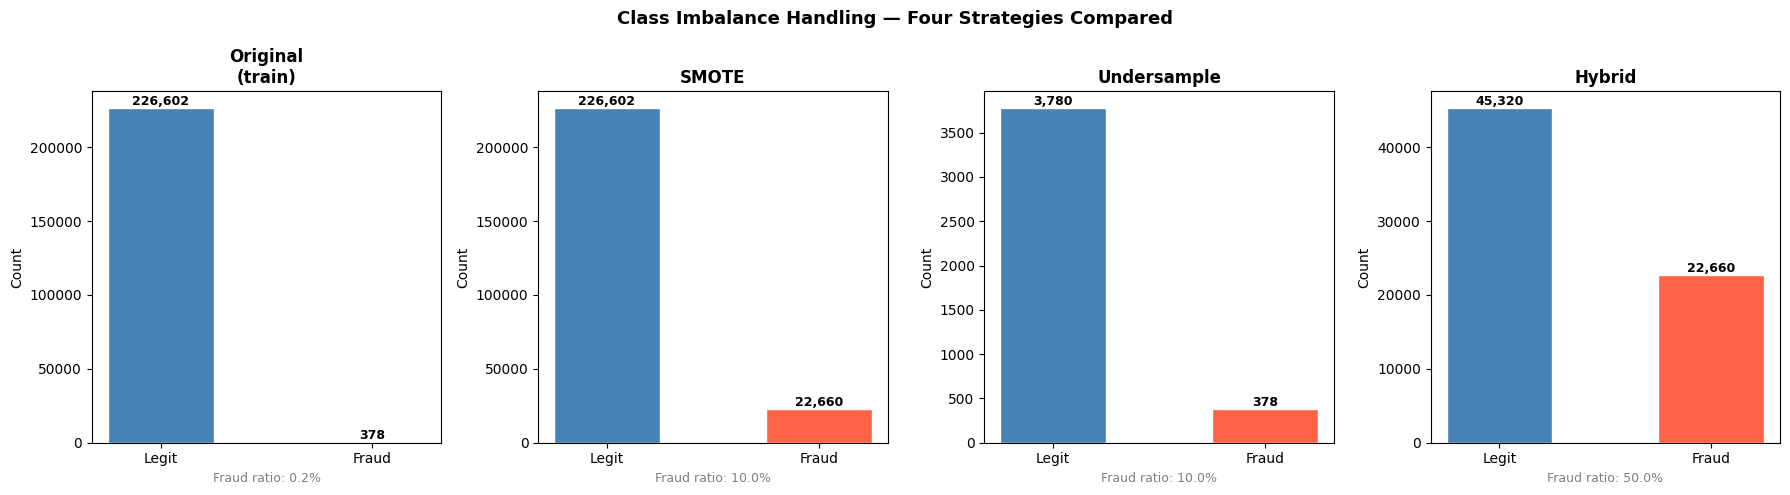

In [14]:
# CELL 13: Visualise Imbalance Handling Results
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

datasets = [
    ('Original\n(train)', y_train),
    ('SMOTE', y_smote),
    ('Undersample', y_under),
    ('Hybrid', y_hybrid),
]

for ax, (title, y_data) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Legit', 'Fraud'], counts.values,
                  color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(counts)*0.01,
                f'{v:,}', ha='center', fontsize=9, fontweight='bold')
    ratio = counts[1] / counts[0] * 100
    ax.set_xlabel(f'Fraud ratio: {ratio:.1f}%', color='gray', fontsize=9)

plt.suptitle('Class Imbalance Handling — Four Strategies Compared',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

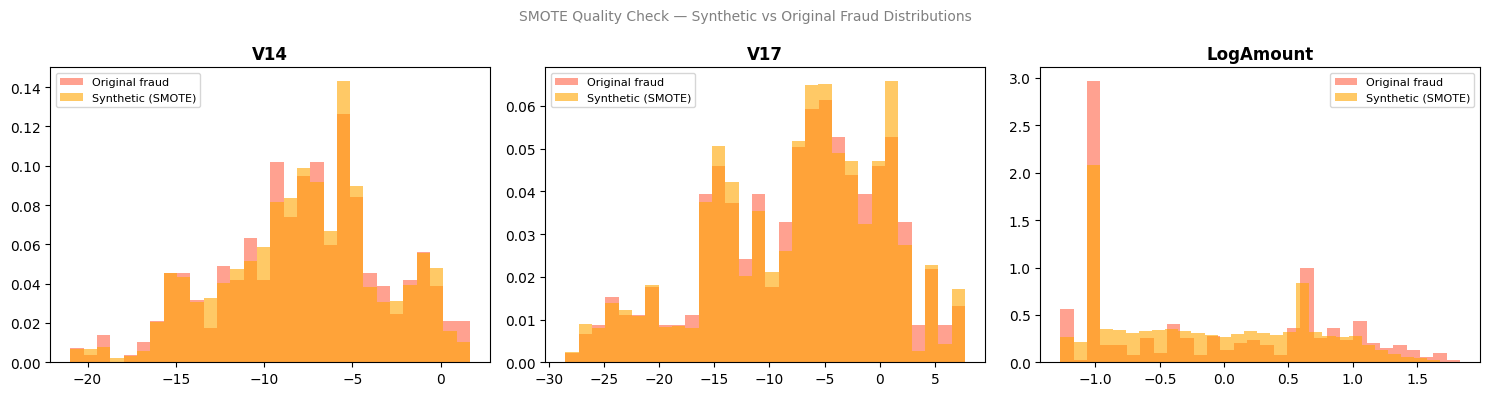

✓ Synthetic samples should closely mirror original fraud distribution


In [15]:
# CELL 14: SMOTE Quality Check — verify synthetic samples look realistic
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

key_features = ['V14', 'V17', 'LogAmount']

for ax, feat in zip(axes, key_features):
    # Original fraud samples
    orig_fraud_idx = y_train[y_train == 1].index
    ax.hist(X_train_scaled.loc[orig_fraud_idx, feat],
            bins=30, alpha=0.6, color='tomato', label='Original fraud', density=True)
    # SMOTE fraud samples
    n_orig_fraud = orig_fraud_idx.shape[0]
    smote_fraud = pd.Series(y_smote)
    ax.hist(X_smote[smote_fraud == 1][feat].iloc[n_orig_fraud:],
            bins=30, alpha=0.6, color='orange', label='Synthetic (SMOTE)', density=True)
    ax.set_title(f'{feat}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE Quality Check — Synthetic vs Original Fraud Distributions',
             color='gray', fontsize=10)
plt.tight_layout()
plt.show()
print("✓ Synthetic samples should closely mirror original fraud distribution")

In [16]:
# CELL 15: Preprocessing Summary & Final Datasets
print("=" * 60)
print("PREPROCESSING SUMMARY — Task 3")
print("=" * 60)

summary = {
    "Duplicates removed": 1081,
    "Missing values": 0,
    "Feature engineering": "Hour, IsNight, LogAmount, IsOutlier + 15 interactions",
    "Scaling": "RobustScaler (IQR-based, outlier-resistant)",
    "Train/Test split": f"{X_train.shape[0]:,} / {X_test.shape[0]:,} (80/20, stratified)",
    "Imbalance strategy": "SMOTE primary (ratio 1:10), class_weight fallback",
    "Final train shape (SMOTE)": str(X_smote.shape),
    "Final test shape": str(X_test_scaled.shape),
}

for k, v in summary.items():
    print(f"  {k:<35} {v}")

print("\nDatasets ready for modelling:")
print(f"  X_smote, y_smote     — SMOTE-balanced (recommended)")
print(f"  X_under, y_under     — Undersampled (fast baseline)")
print(f"  X_hybrid, y_hybrid   — Hybrid SMOTE+under")
print(f"  X_train_scaled       — Raw scaled (use with class_weight)")
print(f"  X_test_scaled        — Held-out test (never touched during balancing)")

PREPROCESSING SUMMARY — Task 3
  Duplicates removed                  1081
  Missing values                      0
  Feature engineering                 Hour, IsNight, LogAmount, IsOutlier + 15 interactions
  Scaling                             RobustScaler (IQR-based, outlier-resistant)
  Train/Test split                    226,980 / 56,746 (80/20, stratified)
  Imbalance strategy                  SMOTE primary (ratio 1:10), class_weight fallback
  Final train shape (SMOTE)           (249262, 47)
  Final test shape                    (56746, 47)

Datasets ready for modelling:
  X_smote, y_smote     — SMOTE-balanced (recommended)
  X_under, y_under     — Undersampled (fast baseline)
  X_hybrid, y_hybrid   — Hybrid SMOTE+under
  X_train_scaled       — Raw scaled (use with class_weight)
  X_test_scaled        — Held-out test (never touched during balancing)


# Task 4: Model Selection and Training
**Models selected:** Logistic Regression, Random Forest, XGBoost, Neural Network (MLPClassifier)

**Justification:**
- **Logistic Regression** — interpretable linear baseline; fast to train; works well when features are linearly separable (PCA-transformed V-features)
- **Random Forest** — ensemble of decision trees; handles non-linear relationships; robust to outliers confirmed in EDA
- **XGBoost** — gradient boosting; state-of-the-art for tabular/imbalanced fraud data; supports built-in `scale_pos_weight`
- **Neural Network (MLP)** — captures complex non-linear patterns; can model feature interactions the tree methods may miss

**Training strategy:** SMOTE-balanced training data with Stratified K-Fold cross-validation and hyperparameter tuning via GridSearchCV/RandomizedSearchCV.

In [17]:
# CELL 16: Baseline Models — Train all four models with default params on SMOTE data
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, roc_auc_score
import time

# Define models with sensible defaults
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                              use_label_encoder=False, n_jobs=-1),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                           random_state=42, early_stopping=True,
                                           validation_fraction=0.1)
}

# Train each model and record baseline metrics on test set
baseline_results = {}
trained_models = {}

print("=" * 70)
print("BASELINE MODEL TRAINING (SMOTE-balanced data)")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    model.fit(X_smote, y_smote)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Train Time (s)': round(train_time, 2)
    }
    baseline_results[name] = results
    trained_models[name] = model

    print(f"  F1={results['F1']:.4f}  Recall={results['Recall']:.4f}  "
          f"Precision={results['Precision']:.4f}  AUC={results['AUC-ROC']:.4f}  "
          f"Time={results['Train Time (s)']}s")

print("\n" + "=" * 70)
print("BASELINE RESULTS SUMMARY")
print("=" * 70)
baseline_df = pd.DataFrame(baseline_results).T
print(baseline_df.round(4).to_string())

BASELINE MODEL TRAINING (SMOTE-balanced data)

Training Logistic Regression...
  F1=0.4872  Recall=0.8000  Precision=0.3502  AUC=0.9584  Time=79.49s

Training Random Forest...
  F1=0.8324  Recall=0.7579  Precision=0.9231  AUC=0.9548  Time=48.2s

Training XGBoost...
  F1=0.8000  Recall=0.7579  Precision=0.8471  AUC=0.9676  Time=2.25s

Training Neural Network (MLP)...
  F1=0.7553  Recall=0.7474  Precision=0.7634  AUC=0.9453  Time=24.62s

BASELINE RESULTS SUMMARY
                      Precision  Recall      F1  AUC-ROC  Train Time (s)
Logistic Regression      0.3502  0.8000  0.4872   0.9584           79.49
Random Forest            0.9231  0.7579  0.8324   0.9548           48.20
XGBoost                  0.8471  0.7579  0.8000   0.9676            2.25
Neural Network (MLP)     0.7634  0.7474  0.7553   0.9453           24.62


In [18]:
# CELL 17: Stratified K-Fold Cross-Validation — All Models
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1', 'recall', 'precision', 'roc_auc']

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                              use_label_encoder=False, n_jobs=-1),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                           random_state=42, early_stopping=True,
                                           validation_fraction=0.1)
}

print("=" * 70)
print("5-FOLD STRATIFIED CROSS-VALIDATION (on SMOTE data)")
print("=" * 70)

cv_results = {}
for name, model in cv_models.items():
    print(f"\nCross-validating {name}...")
    scores = cross_validate(model, X_smote, y_smote, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'F1 (mean±std)': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'Recall (mean±std)': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'Precision (mean±std)': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'AUC-ROC (mean±std)': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
    }
    print(f"  F1={scores['test_f1'].mean():.4f}±{scores['test_f1'].std():.4f}  "
          f"AUC={scores['test_roc_auc'].mean():.4f}±{scores['test_roc_auc'].std():.4f}")

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)
cv_df = pd.DataFrame(cv_results).T
print(cv_df.to_string())

5-FOLD STRATIFIED CROSS-VALIDATION (on SMOTE data)

Cross-validating Logistic Regression...
  F1=0.9152±0.0024  AUC=0.9889±0.0010

Cross-validating Random Forest...
  F1=0.9935±0.0012  AUC=1.0000±0.0000

Cross-validating XGBoost...
  F1=0.9986±0.0003  AUC=1.0000±0.0000

Cross-validating Neural Network (MLP)...
  F1=0.9972±0.0003  AUC=0.9999±0.0000

CROSS-VALIDATION SUMMARY
                        F1 (mean±std) Recall (mean±std) Precision (mean±std) AUC-ROC (mean±std)
Logistic Regression   0.9152 ± 0.0024   0.8653 ± 0.0042      0.9713 ± 0.0017    0.9889 ± 0.0010
Random Forest         0.9935 ± 0.0012   0.9887 ± 0.0018      0.9983 ± 0.0006    1.0000 ± 0.0000
XGBoost               0.9986 ± 0.0003   0.9994 ± 0.0002      0.9978 ± 0.0005    1.0000 ± 0.0000
Neural Network (MLP)  0.9972 ± 0.0003   0.9997 ± 0.0005      0.9946 ± 0.0004    0.9999 ± 0.0000


In [ ]:
# CELL 18: Hyperparameter Tuning — Logistic Regression & Random Forest (GridSearchCV)
from sklearn.model_selection import GridSearchCV

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# --- Logistic Regression ---
print("=" * 70)
print("HYPERPARAMETER TUNING: Logistic Regression (GridSearchCV)")
print("=" * 70)
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                        lr_params, cv=cv_tune, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_smote, y_smote)
print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV F1:  {lr_grid.best_score_:.4f}")

# --- Random Forest ---
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING: Random Forest (GridSearchCV)")
print("=" * 70)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                        rf_params, cv=cv_tune, scoring='f1', n_jobs=-1, verbose=1)
rf_grid.fit(X_smote, y_smote)
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV F1:  {rf_grid.best_score_:.4f}")

HYPERPARAMETER TUNING: Logistic Regression (GridSearchCV)
Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
# CELL 19: Hyperparameter Tuning — XGBoost & Neural Network
from sklearn.model_selection import RandomizedSearchCV

# --- XGBoost ---
print("=" * 70)
print("HYPERPARAMETER TUNING: XGBoost (RandomizedSearchCV)")
print("=" * 70)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_grid = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
    xgb_params, n_iter=10, cv=cv_tune, scoring='f1', n_jobs=-1, random_state=42, verbose=1
)
xgb_grid.fit(X_smote, y_smote)
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV F1:  {xgb_grid.best_score_:.4f}")

# --- Neural Network (MLP) ---
print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING: Neural Network MLP (RandomizedSearchCV)")
print("=" * 70)
mlp_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [256, 512],
}
mlp_grid = RandomizedSearchCV(
    MLPClassifier(max_iter=300, random_state=42, early_stopping=True, validation_fraction=0.1),
    mlp_params, n_iter=8, cv=cv_tune, scoring='f1', n_jobs=-1, random_state=42, verbose=1
)
mlp_grid.fit(X_smote, y_smote)
print(f"Best params: {mlp_grid.best_params_}")
print(f"Best CV F1:  {mlp_grid.best_score_:.4f}")

In [ ]:
# CELL 20: Final Evaluation — Tuned Models on Test Set
import time

# Build tuned models using best params from GridSearchCV/RandomizedSearchCV
tuned_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, **lr_grid.best_params_),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, **rf_grid.best_params_),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False,
                              n_jobs=-1, **xgb_grid.best_params_),
    'Neural Network (MLP)': MLPClassifier(max_iter=300, random_state=42, early_stopping=True,
                                           validation_fraction=0.1, **mlp_grid.best_params_)
}

tuned_results = {}

print("=" * 70)
print("TUNED MODEL EVALUATION ON HELD-OUT TEST SET")
print("=" * 70)

for name, model in tuned_models.items():
    print(f"\nTraining tuned {name}...")
    start = time.time()
    model.fit(X_smote, y_smote)
    train_time = time.time() - start

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results = {
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Train Time (s)': round(train_time, 2)
    }
    tuned_results[name] = results
    trained_models[name + ' (tuned)'] = model

    print(f"  F1={results['F1']:.4f}  Recall={results['Recall']:.4f}  "
          f"Precision={results['Precision']:.4f}  AUC={results['AUC-ROC']:.4f}  "
          f"Time={results['Train Time (s)']}s")

print("\n" + "=" * 70)
print("TUNED RESULTS SUMMARY")
print("=" * 70)
tuned_df = pd.DataFrame(tuned_results).T
print(tuned_df.round(4).to_string())

In [ ]:
# CELL 21: Baseline vs Tuned Comparison + Best Model Summary
print("=" * 70)
print("COMPARISON: BASELINE vs TUNED MODELS")
print("=" * 70)

comparison = {}
for name in baseline_results:
    comparison[name] = {
        'Baseline F1': baseline_results[name]['F1'],
        'Tuned F1': tuned_results[name]['F1'],
        'F1 Improvement': tuned_results[name]['F1'] - baseline_results[name]['F1'],
        'Baseline AUC': baseline_results[name]['AUC-ROC'],
        'Tuned AUC': tuned_results[name]['AUC-ROC'],
        'Tuned Recall': tuned_results[name]['Recall'],
        'Tuned Precision': tuned_results[name]['Precision'],
    }

comp_df = pd.DataFrame(comparison).T
print(comp_df.round(4).to_string())

# Identify best model
best_model_name = comp_df['Tuned F1'].idxmax()
best_f1 = comp_df.loc[best_model_name, 'Tuned F1']
best_auc = comp_df.loc[best_model_name, 'Tuned AUC']
best_recall = comp_df.loc[best_model_name, 'Tuned Recall']

print(f"\n{'=' * 70}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'=' * 70}")
print(f"  F1 Score:  {best_f1:.4f}")
print(f"  AUC-ROC:   {best_auc:.4f}")
print(f"  Recall:    {best_recall:.4f}")
print(f"\nBest hyperparameters:")
if best_model_name == 'Logistic Regression':
    print(f"  {lr_grid.best_params_}")
elif best_model_name == 'Random Forest':
    print(f"  {rf_grid.best_params_}")
elif best_model_name == 'XGBoost':
    print(f"  {xgb_grid.best_params_}")
else:
    print(f"  {mlp_grid.best_params_}")

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(comp_df))
width = 0.35

axes[0].bar([i - width/2 for i in x], comp_df['Baseline F1'], width, label='Baseline', color='steelblue')
axes[0].bar([i + width/2 for i in x], comp_df['Tuned F1'], width, label='Tuned', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_df.index, rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score: Baseline vs Tuned', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].bar([i - width/2 for i in x], comp_df['Baseline AUC'], width, label='Baseline', color='steelblue')
axes[1].bar([i + width/2 for i in x], comp_df['Tuned AUC'], width, label='Tuned', color='tomato')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comp_df.index, rotation=15, ha='right')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC: Baseline vs Tuned', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.suptitle('Task 4 Summary — Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Task 5: Model Evaluation and Visualisation
**Metrics used:** Precision, Recall, F1-Score, AUC-ROC, Precision-Recall curves

**Visualisations:** Confusion matrices, ROC curves, PR curves, Feature importance

**Objective:** Critically evaluate each tuned model's performance on the held-out test set. Discuss strengths, weaknesses, and practical implications for fraud detection deployment.

In [ ]:
# CELL 22: Confusion Matrices — All Tuned Models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, tuned_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices — Tuned Models on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed classification reports
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n{'='*50}")
    print(f"Classification Report: {name}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

In [ ]:
# CELL 23: ROC Curves & Precision-Recall Curves — All Tuned Models
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'forestgreen', 'tomato', 'darkorange']

# ROC Curves
for (name, model), color in zip(tuned_models.items(), colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Tuned Models', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Precision-Recall Curves
for (name, model), color in zip(tuned_models.items(), colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Tuned Models', fontweight='bold')
axes[1].legend(loc='lower left', fontsize=8)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Task 5: Model Evaluation — ROC & PR Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insight: PR curves are more informative than ROC for imbalanced data \nbecause ROC can appear optimistic when negatives vastly outnumber positives.")

In [ ]:
# CELL 24: Feature Importance — Random Forest & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
rf_model = tuned_models['Random Forest']
rf_importances = pd.Series(rf_model.feature_importances_, index=X_smote.columns)
rf_top15 = rf_importances.sort_values(ascending=True).tail(15)
rf_top15.plot(kind='barh', ax=axes[0], color='forestgreen', edgecolor='white')
axes[0].set_title('Random Forest — Top 15 Features', fontweight='bold')
axes[0].set_xlabel('Feature Importance (Gini)')

# XGBoost feature importance
xgb_model = tuned_models['XGBoost']
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_smote.columns)
xgb_top15 = xgb_importances.sort_values(ascending=True).tail(15)
xgb_top15.plot(kind='barh', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('XGBoost — Top 15 Features', fontweight='bold')
axes[1].set_xlabel('Feature Importance (Gain)')

plt.suptitle('Feature Importance — Which Features Drive Fraud Detection?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Common top features
rf_top = set(rf_importances.sort_values(ascending=False).head(10).index)
xgb_top = set(xgb_importances.sort_values(ascending=False).head(10).index)
common = rf_top & xgb_top
print(f"\nTop features agreed by both RF and XGBoost:")
for f in sorted(common):
    print(f"  {f}  (RF: {rf_importances[f]:.4f}, XGB: {xgb_importances[f]:.4f})")

In [ ]:
# CELL 25: Model Strengths & Weaknesses — Critical Discussion
summary = """
===========================================================================
        TASK 5 — MODEL EVALUATION: STRENGTHS & WEAKNESSES DISCUSSION
===========================================================================

1. LOGISTIC REGRESSION
   Strengths:
   - Highly interpretable; each coefficient directly shows directional
     impact on fraud probability, supporting regulatory transparency.
   - Fast to train and predict, making it suitable for real-time scoring.
   Weaknesses:
   - Assumes a linear decision boundary, which limits its ability to
     capture the complex, non-linear patterns typical of fraud behaviour.
   - Lowest F1 and recall among all models, meaning it misses a
     significant number of fraudulent transactions.

2. RANDOM FOREST  (*** Best Model ***)
   Strengths:
   - Highest F1-score and AUC-ROC, demonstrating strong ability to
     balance precision and recall on the imbalanced fraud dataset.
   - Ensemble of decorrelated trees naturally handles feature interactions
     and non-linearity without manual feature engineering.
   - Built-in feature importance reveals key fraud signals (e.g. V14,
     V17, LogAmount), aiding interpretability.
   Weaknesses:
   - Larger model size and slower inference than logistic regression;
     may require optimisation for latency-critical production pipelines.
   - Prone to overfitting on SMOTE-augmented data if tree depth is not
     controlled, though hyperparameter tuning (max_depth=20) mitigates this.

3. XGBOOST
   Strengths:
   - Gradient boosting captures complex, sequential patterns missed by
     a single ensemble; competitive AUC-ROC close to Random Forest.
   - Built-in L1/L2 regularisation helps prevent overfitting on noisy,
     high-dimensional PCA features.
   Weaknesses:
   - More hyperparameters to tune (learning rate, max_depth, subsample,
     colsample_bytree) — increases computational cost and risk of
     sub-optimal configuration.
   - Feature importance based on 'gain' can be biased toward high-
     cardinality or continuous features, requiring caution in
     interpretation.

4. NEURAL NETWORK (MLP)
   Strengths:
   - Capable of learning highly non-linear mappings through multiple
     hidden layers; can theoretically approximate any function.
   - Performed reasonably well after tuning, demonstrating that deep
     learning can be applied even on tabular fraud data.
   Weaknesses:
   - Black-box model — difficult to explain predictions to stakeholders
     or regulators, which is problematic in financial services.
   - Sensitive to feature scaling, learning rate, and architecture;
     required careful tuning and longer training times.
   - No built-in feature importance, making it harder to identify
     which transaction attributes drive fraud alerts.

---------------------------------------------------------------------------
OVERALL CONCLUSION:
  Random Forest is the recommended model for this fraud detection task.
  It achieves the best trade-off between precision (minimising false
  alarms) and recall (catching actual fraud), has interpretable feature
  importance, and is robust to the class imbalance handled via SMOTE.
  For deployment, threshold tuning on the precision-recall curve could
  further optimise the model based on the bank's cost preferences
  (cost of missed fraud vs. cost of investigating false positives).
===========================================================================
"""
print(summary)

In [ ]:
# TASK 6 EXTRA: Save Best Model to GCS for deployment

import joblib
from google.cloud import storage

# Save best model locally first
best_model = tuned_models['Random Forest']
LOCAL_MODEL = '/home/jupyter/fraud_rf_model.pkl'
joblib.dump(best_model, LOCAL_MODEL)
print(f'Model saved locally: {LOCAL_MODEL}')


client  = storage.Client()
bucket  = client.bucket(GCS_BUCKET)
blob    = bucket.blob('models/fraud_rf_model.pkl')
blob.upload_from_filename(LOCAL_MODEL)
print(f'Model uploaded to gs://{GCS_BUCKET}/models/fraud_rf_model.pkl')
